# Empirical vs Simulated Brain — Rotating & Static GIFs

Render the **empirical** and **Hybrid Hopf (simulated)** brain activity side by side and export animated GIFs. Two animations are produced:

1. A **rotating** view that spins the brain around the vertical (z) axis.
2. A **static** view fixed at a single camera angle.

Both animate the activity over simulated timesteps. Setup cells (data, models, surface adapter) are inherited from `empirical_vs_simulated_brain.ipynb`; the plotting at the bottom uses a small custom 3D renderer (the project's `plotColorView` only supports fixed 2D views).

> Start small: the config below simulates just **2 timesteps** to validate the pipeline. Bump `N_TIMEPOINTS` / `N_FRAMES` up later for a longer, smoother animation.

In [21]:
import io
import os
import sys
import subprocess
from contextlib import redirect_stdout
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib
import numpy as np
import torch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm
from nilearn import datasets, surface
from scipy import stats

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'examples':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

In [22]:
WHOLEBRAIN_URL = 'https://github.com/dagush/WholeBrain.git'
WHOLEBRAIN_DIR = PROJECT_ROOT / '.cache' / 'WholeBrain'

if not WHOLEBRAIN_DIR.exists():
    WHOLEBRAIN_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', '--depth', '1', WHOLEBRAIN_URL, str(WHOLEBRAIN_DIR)],
        check=True,
    )

if str(WHOLEBRAIN_DIR) not in sys.path:
    sys.path.insert(0, str(WHOLEBRAIN_DIR))

from WholeBrain.Utils.Plotting.plot3DBrain import plotColorView

wholebrain_commit = subprocess.check_output(
    ['git', '-C', str(WHOLEBRAIN_DIR), 'rev-parse', '--short', 'HEAD'],
    text=True,
).strip()
print(f'WholeBrain commit: {wholebrain_commit}')

WholeBrain commit: 0acef9b


## Configuration

`TIMESTEP` selects which frame of the trajectory is rendered. `SUBJECT_INDEX` picks which subject from the batch to use; the other models inherit the same initial state so the comparison is paired.

In [ ]:
DATASET_TYPE = 'ts_young'
DATA_PATH = 'data/ts_young/ts_young_TR0.72.mat'
LSD_DATA_DIR = 'data/lsd'
CHECKPOINT_DIR = 'checkpoints'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

SUBJECT_INDEX = 0     # <-- which subject in the batch to animate

# --- Data loading: kept identical to empirical_vs_simulated_brain.ipynb so the
#     same windows/subjects are loaded. Only the simulation length below is small. ---
N_TIMEPOINTS = 120
MAX_PATHS = 2

# --- Small simulation for now; bump N_SIM_STEPS up later for a longer GIF. ---
N_SIM_STEPS = 24*4          # number of timesteps the model simulates

# Frame counts are decoupled from the simulation length: the static GIF shows one
# frame per simulated step, while the rotating GIF needs enough azimuth samples to
# read as a smooth turntable about the vertical axis (activity is spread across them).
N_STATIC_FRAMES = N_SIM_STEPS   # static gif: one frame per simulated timestep
N_ROT_FRAMES = 24*4               # rotating gif: azimuth samples over a full 360 turn

MODEL_NAME = 'Hybrid Hopf'
MODELS_TO_PLOT = [MODEL_NAME]

SURFACE_MESH = 'fsaverage5'
SURFACE_KIND = 'pial'
CMAP_VALUE = 'viridis'

# --- GIF / camera parameters ---
GIF_ELEV = 15          # camera elevation (degrees above horizontal)
GIF_AZIM0 = 0          # starting azimuth: lateral profile (degrees)
GIF_FPS = 8            # frames per second
GIF_FIGSIZE = (8.0, 4.0)
GIF_DPI = 110
LIGHTING_BIAS = 0.45

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SAVE_DIR = PROJECT_ROOT / 'paper' / 'images' / 'wholebrain' / 'gifs'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device       : {DEVICE}')
print(f'Load T       : {N_TIMEPOINTS}')
print(f'Sim steps    : {N_SIM_STEPS}')
print(f'Static frames: {N_STATIC_FRAMES}')
print(f'Rotate frames: {N_ROT_FRAMES}')
print(f'Subject idx  : {SUBJECT_INDEX}')
print(f'Save dir     : {SAVE_DIR}')

Device       : cpu
Load T       : 120
Sim steps    : 96
Static frames: 96
Rotate frames: 48
Subject idx  : 0
Save dir     : /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/gifs


In [24]:
from src.dataset import create_data_loaders, load_dataset
from src.training import HopfConfig

cfg = HopfConfig()
cfg.dataset_type = DATASET_TYPE
cfg.data_path = DATA_PATH
cfg.lsd_data_dir = LSD_DATA_DIR
cfg.use_wandb = False
cfg.dt_min = 0.05

dataset = load_dataset(cfg, DEVICE)
window_size = min(N_TIMEPOINTS, dataset.n_timepoints // 2)

_, _, _, test_intra_loader = create_data_loaders(
    dataset=dataset,
    window_size=window_size,
    batch_size=cfg.batch_size,
    n_windows_per_epoch=cfg.n_windows_per_epoch,
    train_ratio=cfg.train_ratio,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
    device=DEVICE,
)

batch = next(iter(test_intra_loader))
if len(batch) == 4:
    ts_target, _, patient_ids, control = batch
elif len(batch) == 3:
    ts_target, _, patient_ids = batch
    control = None
else:
    raise ValueError(f'Unexpected batch structure: {len(batch)} items')

ts_target = ts_target[:MAX_PATHS, :, :N_TIMEPOINTS]
if control is not None:
    control = control[:MAX_PATHS]
initial_state = ts_target[:, :, 0]

print(f'n_rois       : {dataset.n_rois}')
print(f'n_timepoints : {dataset.n_timepoints}')
print(f'target batch : {tuple(ts_target.shape)}')

Loaded dataset:
  - subjects=94  ROIs=100  T=1200
  - FC shape=torch.Size([100, 100])  dtype=torch.complex64  dt=0.72s
  - control_dims=0
n_rois       : 100
n_timepoints : 1200
target batch : (2, 100, 120)


In [25]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ('gnn_hopf', 'GNN Hopf'),
    ('hybrid_neural', 'Hybrid+Neural'),
    ('hybrid_hopf', 'Hybrid Hopf'),
    ('nsde', 'Neural SDE'),
    ('hopf', 'Hopf'),
]


def short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (' (Grid)' if 'grid' in lower else '')
    return stem


models = {}
for ckpt_path in sorted(Path(CHECKPOINT_DIR).glob(f'*{DATASET_TYPE}*.pt')):
    model, model_type, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
    label = short_label(ckpt_path.stem)
    if model.n_rois != dataset.n_rois:
        continue
    if label not in MODELS_TO_PLOT:
        continue
    if label in models:
        continue
    models[label] = model
    print(f'Loaded {label:16s} ({model_type})')

missing = [name for name in MODELS_TO_PLOT if name not in models]
if missing:
    print(f'Warning: no checkpoint found for {missing}')

Loaded Hybrid Hopf      (HybridHopfModel)


In [26]:
def forward_kwargs_for(model) -> dict:
    kwargs = {'n_steps': N_SIM_STEPS}
    if control is not None and getattr(model, 'n_control_dims', 0) > 0 and control.shape[-1] > 0:
        kwargs['control'] = control
    return kwargs

# Empirical series, sliced to the same short horizon as the simulation.
ts_empirical = ts_target[:, :, :N_SIM_STEPS]

ts_preds = {}
for name, model in models.items():
    with torch.no_grad():
        ts_preds[name] = model.forward(initial_state=initial_state, **forward_kwargs_for(model)).cpu()
    print(f'{name:16s} -> {tuple(ts_preds[name].shape)}')
print(f'empirical        -> {tuple(ts_empirical.shape)}')

Hybrid Hopf      -> (2, 100, 96)
empirical        -> (2, 100, 96)


## Surface adapter and comparison helper

`build_schaefer_cortex` returns the fsaverage mesh and the Schaefer parcel-to-vertex map used by `plotColorView`. `prepare_roi_activity` reshapes a prediction tensor into a `(roi, time)` array.

In [27]:
SUPPORTED_SURFACE_ROIS = set(range(100, 1001, 100))


@lru_cache(maxsize=12)
def build_schaefer_cortex(n_rois: int, mesh: str = 'fsaverage5', surface_kind: str = 'pial'):
    if n_rois not in SUPPORTED_SURFACE_ROIS:
        raise ValueError(f'Schaefer parcels must be one of {sorted(SUPPORTED_SURFACE_ROIS)}; got {n_rois}.')

    surface_files = {
        'infl': ('infl_left', 'infl_right'),
        'pial': ('pial_left', 'pial_right'),
        'white': ('white_left', 'white_right'),
    }
    if surface_kind not in surface_files:
        raise ValueError(f"surface_kind must be one of {sorted(surface_files)}, got {surface_kind!r}.")

    atlas = datasets.fetch_atlas_schaefer_2018(n_rois=n_rois, yeo_networks=7, resolution_mm=2)
    labels_img = nib.load(atlas['maps'])
    fsaverage = datasets.fetch_surf_fsaverage(mesh=mesh)

    labels_left = np.rint(
        surface.vol_to_surf(labels_img, fsaverage.pial_left, interpolation='nearest_most_frequent')
    ).astype(int) - 1
    labels_right = np.rint(
        surface.vol_to_surf(labels_img, fsaverage.pial_right, interpolation='nearest_most_frequent')
    ).astype(int) - 1

    surface_left_key, surface_right_key = surface_files[surface_kind]
    return {
        'model_L': nib.load(getattr(fsaverage, surface_left_key)),
        'model_R': nib.load(getattr(fsaverage, surface_right_key)),
        'map_L': labels_left,
        'map_R': labels_right,
    }


def prepare_roi_activity(array_like, *, n_rois: int, subject_index: int = 0, complex_mode: str = 'real'):
    arr = array_like.detach().cpu().numpy() if torch.is_tensor(array_like) else np.asarray(array_like)
    if arr.ndim == 3:
        arr = arr.mean(axis=0) if subject_index is None else arr[int(subject_index)]
    elif arr.ndim != 2:
        raise ValueError(f'Expected a 2-D or 3-D array, got shape {arr.shape}.')

    if np.iscomplexobj(arr):
        if complex_mode == 'real':
            arr = arr.real
        elif complex_mode == 'imag':
            arr = arr.imag
        elif complex_mode == 'abs':
            arr = np.abs(arr)
        else:
            raise ValueError("complex_mode must be one of: 'real', 'imag', 'abs'.")

    arr = np.asarray(arr, dtype=float)
    if arr.shape[0] != n_rois and arr.shape[1] == n_rois:
        arr = arr.T
    if arr.shape[0] != n_rois:
        raise ValueError(f'Could not align timeseries with n_rois={n_rois}. Final shape was {arr.shape}.')
    return arr


# Pre-build the cortex so each per-model cell is fast.
_CORTEX = build_schaefer_cortex(dataset.n_rois, mesh=SURFACE_MESH, surface_kind=SURFACE_KIND)
print('Cortex ready:', sorted(_CORTEX))

[fetch_atlas_schaefer_2018] Dataset found in /home/hpc/dsaa/dsaa110h/nilearn_data/schaefer_2018

Cortex ready: ['map_L', 'map_R', 'model_L', 'model_R']


## 3D brain renderer

`plotColorView` only offers fixed 2D projections, so we build a small 3D renderer on top of matplotlib's 3D axes. Both hemispheres are merged into one mesh, ROI values are broadcast to vertices, and per-face colors get a simple Lambertian shade. Fixed, symmetric axis limits keep the brain centred so every frame is the same pixel size (required for a clean GIF).

In [28]:
from io import BytesIO

from PIL import Image


def build_brain_mesh(cortex):
    """Merge both hemispheres into a single (vertices, faces, region_map)."""
    vtx_L, tri_L = cortex['model_L'].agg_data()
    vtx_R, tri_R = cortex['model_R'].agg_data()
    vertices = np.vstack([vtx_L, vtx_R]).astype(float)
    faces = np.vstack([tri_L, tri_R + len(vtx_L)]).astype(int)
    region_map = np.concatenate([cortex['map_L'], cortex['map_R']]).astype(int)
    return vertices, faces, region_map


def vertex_values_from_rois(roi_values, region_map):
    """Broadcast per-ROI values onto vertices; unassigned vertices (-1) -> 0."""
    vals = np.zeros(len(region_map), dtype=float)
    valid = region_map >= 0
    vals[valid] = np.asarray(roi_values, dtype=float)[region_map[valid]]
    return vals


def _zscore(values: np.ndarray) -> np.ndarray:
    centered = values - np.nanmean(values)
    return centered / (np.nanstd(centered) + 1e-6)


# Build the mesh once and precompute geometry used every frame.
BRAIN_VERTICES, BRAIN_FACES, BRAIN_REGION_MAP = build_brain_mesh(_CORTEX)

# Face normals for simple Lambertian shading (fixed in object space).
_fv = BRAIN_VERTICES[BRAIN_FACES]
_fn = np.cross(_fv[:, 1] - _fv[:, 0], _fv[:, 2] - _fv[:, 0])
BRAIN_FACE_NORMALS = _fn / (np.linalg.norm(_fn, axis=1, keepdims=True) + 1e-9)
_LIGHT_DIR = np.array([0.3, 0.4, 0.9]); _LIGHT_DIR = _LIGHT_DIR / np.linalg.norm(_LIGHT_DIR)

# Symmetric, fixed limits centred on the mesh so rotation never clips or resizes.
_center = BRAIN_VERTICES.mean(axis=0)
_radius = float(np.abs(BRAIN_VERTICES - _center).max()) * 1.02
BRAIN_LIMITS = np.array([_center - _radius, _center + _radius])

print('mesh vertices:', BRAIN_VERTICES.shape, ' faces:', BRAIN_FACES.shape)
print('limits:', BRAIN_LIMITS[0].round(1), '->', BRAIN_LIMITS[1].round(1))


def render_brain_panel(ax, vertex_values, *, azim, elev, cmap, norm,
                       lighting_bias=0.45, zoom=1.5):
    """Draw the shaded, value-coloured brain on a 3D axis at the given camera angle."""
    x, y, z = BRAIN_VERTICES.T
    tris = ax.plot_trisurf(x, y, z, triangles=BRAIN_FACES,
                           linewidth=0.0, antialiased=False, shade=False)

    face_vals = vertex_values[BRAIN_FACES].mean(axis=1)
    rgba = np.asarray(cmap(norm(face_vals)))
    shade = lighting_bias + (1.0 - lighting_bias) * np.clip(
        BRAIN_FACE_NORMALS @ _LIGHT_DIR, 0.0, 1.0
    )
    rgba[:, :3] *= shade[:, None]
    tris.set_fc(rgba)

    ax.set_xlim(BRAIN_LIMITS[0, 0], BRAIN_LIMITS[1, 0])
    ax.set_ylim(BRAIN_LIMITS[0, 1], BRAIN_LIMITS[1, 1])
    ax.set_zlim(BRAIN_LIMITS[0, 2], BRAIN_LIMITS[1, 2])
    # zoom > 1 enlarges the brain within the axes, trimming the wide empty margin
    # that 3D axes leave around the rendered surface.
    ax.set_box_aspect((1, 1, 1), zoom=zoom)
    # vertical_axis='z' makes azim an explicit spin about the vertical (superior-inferior)
    # anatomical axis, which is the z column of the fsaverage coordinates.
    ax.view_init(elev=elev, azim=azim, vertical_axis='z')
    ax.set_axis_off()
    return tris


def _fig_to_image(fig, dpi):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=dpi)  # no bbox='tight': keep frames same size
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    return img.copy()


def make_brain_gif(emp_ts, sim_ts, save_path, *, rotate, n_frames,
                   subject_index=SUBJECT_INDEX,
                   elev=GIF_ELEV, azim0=GIF_AZIM0, cmap_name=CMAP_VALUE,
                   figsize=GIF_FIGSIZE, dpi=GIF_DPI, fps=GIF_FPS,
                   lighting_bias=LIGHTING_BIAS):
    """Render an Empirical-vs-Simulated GIF.

    ``rotate`` spins the brain a full turn about the vertical (z / superior-inferior)
    axis over ``n_frames``. The simulated activity is spread across those frames, so the
    rotation can be smooth (many frames) even when the simulation is only a few steps.
    """
    emp = prepare_roi_activity(emp_ts, n_rois=dataset.n_rois, subject_index=subject_index)
    sim = prepare_roi_activity(sim_ts, n_rois=dataset.n_rois, subject_index=subject_index)
    n_timesteps = emp.shape[1]

    # Per-timestep z-scores, with a shared symmetric colour range across all frames.
    emp_z = np.stack([_zscore(emp[:, t]) for t in range(n_timesteps)], axis=1)
    sim_z = np.stack([_zscore(sim[:, t]) for t in range(n_timesteps)], axis=1)
    value_lim = max(float(np.percentile(np.abs(np.concatenate([emp_z, sim_z])), 99.0)), 1e-3)
    norm = Normalize(vmin=-value_lim, vmax=value_lim)
    cmap = plt.get_cmap(cmap_name)

    frames = []
    for f in range(n_frames):
        t = (f * n_timesteps) // n_frames          # progress through the simulation
        azim = azim0 + (360.0 * f / n_frames if rotate else 0.0)

        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax_emp = fig.add_subplot(1, 2, 1, projection='3d')
        ax_sim = fig.add_subplot(1, 2, 2, projection='3d')
        render_brain_panel(ax_emp, vertex_values_from_rois(emp_z[:, t], BRAIN_REGION_MAP),
                           azim=azim, elev=elev, cmap=cmap, norm=norm,
                           lighting_bias=lighting_bias)
        render_brain_panel(ax_sim, vertex_values_from_rois(sim_z[:, t], BRAIN_REGION_MAP),
                           azim=azim, elev=elev, cmap=cmap, norm=norm,
                           lighting_bias=lighting_bias)
        ax_emp.set_title('Empirical', fontsize=20, y=0.95)
        ax_sim.set_title('Simulated', fontsize=20, y=0.95)
        # Enlarge and overlap the two panels so the brains sit close together with a
        # small gap and the titles hug them; the panels are transparent so overlapping
        # their bounding boxes is safe (the rendered brains never touch, even at the
        # widest lateral view).
        ax_emp.set_position([-0.04, 0.0, 0.56, 1.0])
        ax_sim.set_position([0.48, 0.0, 0.56, 1.0])
        frames.append(_fig_to_image(fig, dpi))
        plt.close(fig)

    # Guard against any stray size drift before encoding.
    size0 = frames[0].size
    frames = [im if im.size == size0 else im.resize(size0) for im in frames]

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(save_path, save_all=True, append_images=frames[1:],
                   duration=int(1000 / fps), loop=0, optimize=True)
    print(f'Saved {save_path}  ({len(frames)} frames, {frames[0].size[0]}x{frames[0].size[1]})')
    return save_path


mesh vertices: (20484, 3)  faces: (40960, 3)
limits: [ -91.9 -113.3  -74.5] -> [ 92.4  71.  109.7]


## Static GIF

Same side-by-side view at a fixed camera angle; only the activity animates.

Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/gifs/empirical_vs_simulated__hybrid_hopf__static.gif  (96 frames, 880x440)


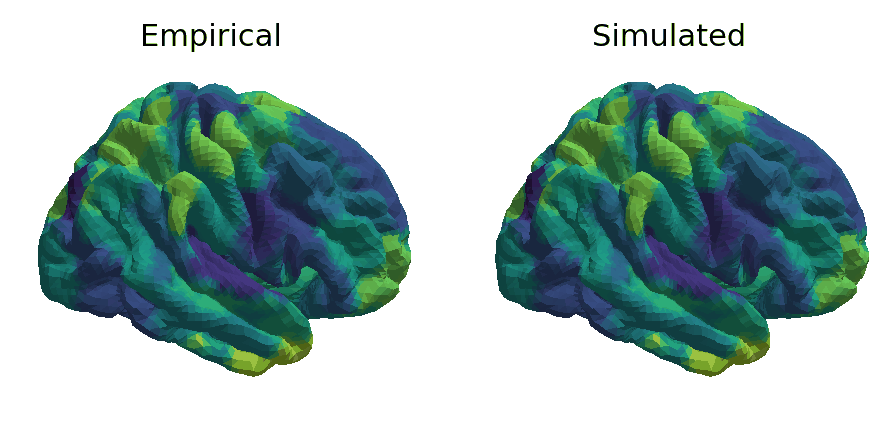

In [29]:
static_path = make_brain_gif(
    ts_empirical,
    ts_preds[MODEL_NAME],
    SAVE_DIR / 'empirical_vs_simulated__hybrid_hopf__static.gif',
    rotate=False,
    n_frames=N_STATIC_FRAMES,
)
IPyImage(filename=str(static_path))

## Rotating GIF

The brain spins a full turn about the vertical (z) axis over the animation.

In [ ]:
from IPython.display import Image as IPyImage

rotating_path = make_brain_gif(
    ts_empirical,
    ts_preds[MODEL_NAME],
    SAVE_DIR / 'empirical_vs_simulated__hybrid_hopf__rotating.gif',
    rotate=True,
    n_frames=N_ROT_FRAMES,
)
IPyImage(filename=str(rotating_path))